# Analisis Backtest MTF Berbasis Evaluasi (Continuous Run)

Dokumen ini memuat implementasi strategi perdagangan kuantitatif Multi-Timeframe (MTF) dengan pendekatan Long-Only. Sistem dievaluasi menggunakan metode *Continuous Run* melintasi berbagai fase pasar pasar, tanpa reset nilai ekuitas antar jendela analisis.

Parameter Utama:
- **Instrumen**: S&P 500 (SPY), NASDAQ 100 (QQQ), Dow Jones (DJI).
- **Filter Makro (1D)**: Tren didefinisikan positif jika `EMA_50 > EMA_100 > EMA_200`. Terdapat pergeseran 1 bar (`.shift(1)`) untuk mencegah bias lihat-ke-depan (*lookahead bias*).
- **Filter Mikro (1H)**: Momentum didukung oleh `MACD Line > MACD Signal` dan area wajar pembelian dibatasi oleh `RSI < 70`.
- **Manajemen Risiko**: Adaptive Trailing Stop dikalkulasi sebesar harga tertinggi sejak pembelian dikurangi `3.0 * ATR(14)`.
- **Sistem Modal**: Compounding penuh, tanpa margin. Modal awal $1,000.
- **Biaya Eksekusi**: Total friksi sebesar 0.03% per transaksi (Komisi 0.02% + Slippage 0.01%).


In [33]:
# =============================================================================
# BLOK 1: PERSIAPAN & LOAD LIBRARY
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("Modul dasar berhasil dimuat.")


Modul dasar berhasil dimuat.


In [34]:
# =============================================================================
# BLOK 2: INGESTI & PEMBERSIHAN DATA (1D dan 1H)
# =============================================================================
def load_and_clean_data(file_path):
    if file_path.endswith('.parquet'):
        df = pd.read_parquet(file_path)
    else:
        df = pd.read_csv(file_path, sep='\t' if '\t' in open(file_path).readline() else ',')
        
    df.columns = [c.lower() for c in df.columns]
    
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
    elif 'date' in df.columns:
        df['datetime'] = pd.to_datetime(df['date'])
        df.drop(columns=['date'], inplace=True, errors='ignore')
    elif 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['time'])
        
    df.sort_values('datetime', inplace=True)
    df.set_index('datetime', inplace=True)
    df['date'] = df.index.date
    return df

try:
    spy_1d = load_and_clean_data('data/spy_US500_D1.parquet')
    spy_1h = load_and_clean_data('data/spy_US500_H1.parquet')
    
    qqq_1d = load_and_clean_data('data/Nasdaq100_1d_data.csv')
    qqq_1h = load_and_clean_data('data/Nasdaq100_1h_data.csv')
    
    dji_1d = load_and_clean_data('data/Dow_Jones_1d_data.csv')
    dji_1h = load_and_clean_data('data/Dow_Jones_1h_data.csv')
    
    print("Data historis berhasil dimuat dan disanitasi.")
    print(f"  SPY (1D: {len(spy_1d):,}, 1H: {len(spy_1h):,})")
    print(f"  QQQ (1D: {len(qqq_1d):,}, 1H: {len(qqq_1h):,})")
    print(f"  DJI (1D: {len(dji_1d):,}, 1H: {len(dji_1h):,})")
except Exception as e:
    print(f"Kesalahan saat memuat data: {e}")



Data historis berhasil dimuat dan disanitasi.
  SPY (1D: 3,627, 1H: 50,172)
  QQQ (1D: 2,283, 1H: 51,889)
  DJI (1D: 2,250, 1H: 49,325)


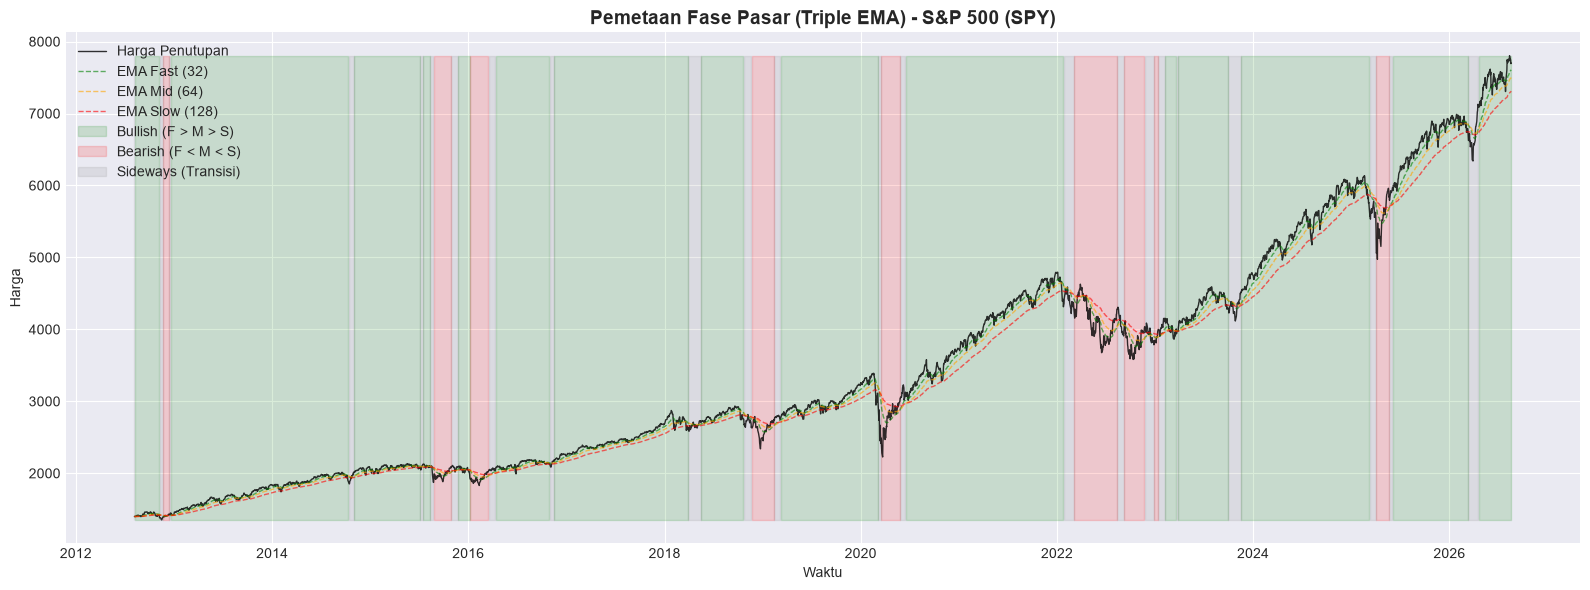

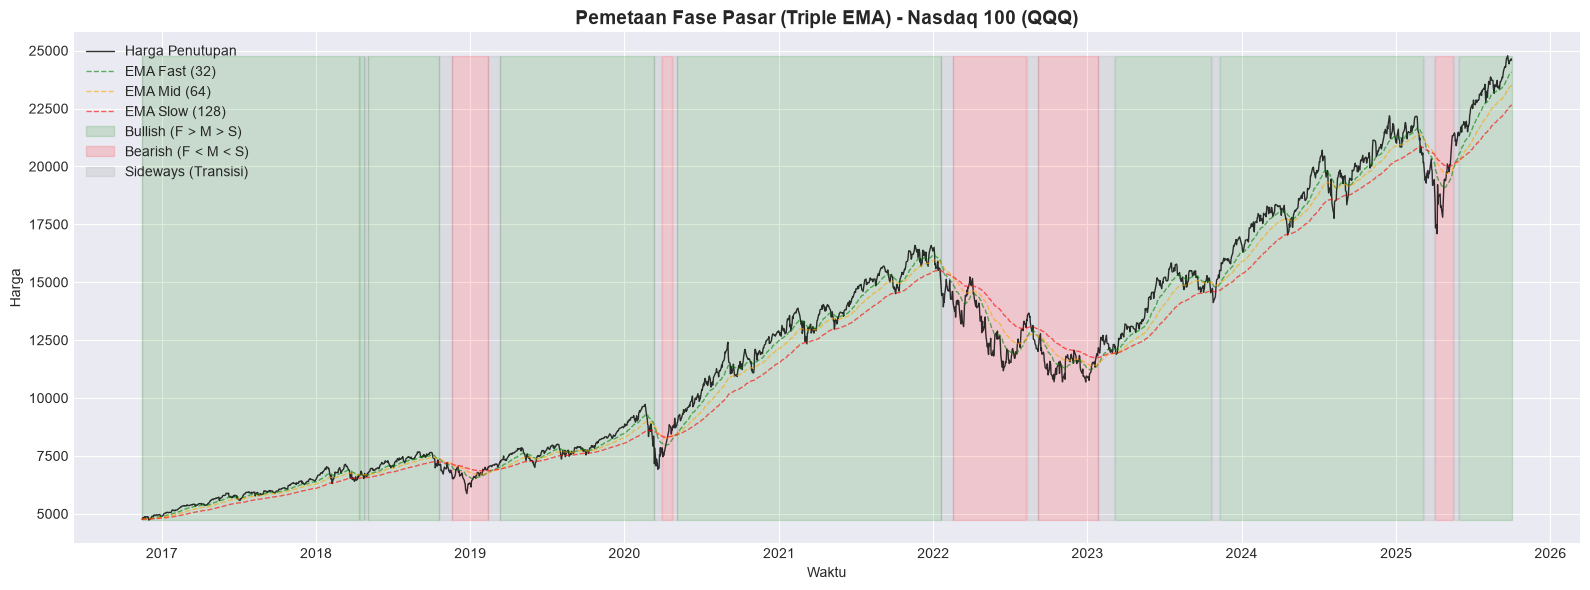

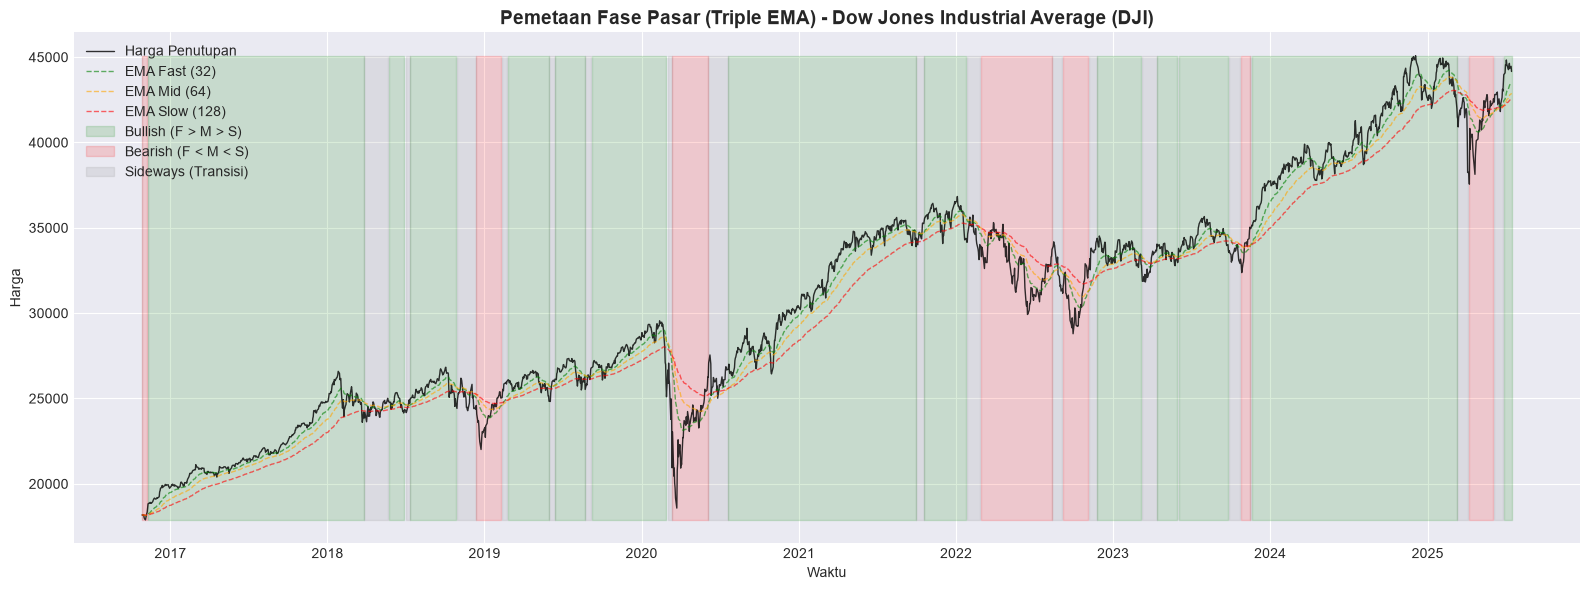

In [35]:
# =============================================================================
# BLOK 3: VISUALISASI EKSPLORATIF (PEMETAAN FASE PASAR)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calc_ema_lokal(series, span):
    return series.ewm(span=span, adjust=False).mean()

def plot_fase_pasar(df_1d, nama_instrumen):
    df_plot = df_1d.copy()
    
    # Hitung Triple EMA untuk penentuan Fase Pasar
    df_plot['ema_fast'] = calc_ema_lokal(df_plot['close'], 32)
    df_plot['ema_mid'] = calc_ema_lokal(df_plot['close'], 64)
    df_plot['ema_slow'] = calc_ema_lokal(df_plot['close'], 128)
    
    # Tentukan Fase Pasar (Berbasis Triple EMA)
    kondisi_bullish = (df_plot['ema_fast'] > df_plot['ema_mid']) & (df_plot['ema_mid'] > df_plot['ema_slow'])
    kondisi_bearish = (df_plot['ema_fast'] < df_plot['ema_mid']) & (df_plot['ema_mid'] < df_plot['ema_slow'])
    
    df_plot['fase_pasar'] = 'Sideways'
    df_plot.loc[kondisi_bullish, 'fase_pasar'] = 'Bullish'
    df_plot.loc[kondisi_bearish, 'fase_pasar'] = 'Bearish'
    
    plt.figure(figsize=(16, 6))
    plt.plot(df_plot.index, df_plot['close'], color='black', linewidth=1, alpha=0.8, label='Harga Penutupan')
    plt.plot(df_plot.index, df_plot['ema_fast'], color='green', linewidth=1, linestyle='--', alpha=0.6, label='EMA Fast (32)')
    plt.plot(df_plot.index, df_plot['ema_mid'], color='orange', linewidth=1, linestyle='--', alpha=0.6, label='EMA Mid (64)')
    plt.plot(df_plot.index, df_plot['ema_slow'], color='red', linewidth=1, linestyle='--', alpha=0.6, label='EMA Slow (128)')
    
    # Mewarnai latar belakang berdasarkan fase
    plt.fill_between(df_plot.index, df_plot['close'].min(), df_plot['close'].max(), 
                     where=(df_plot['fase_pasar'] == 'Bullish'), color='green', alpha=0.15, label='Bullish (F > M > S)')
    plt.fill_between(df_plot.index, df_plot['close'].min(), df_plot['close'].max(), 
                     where=(df_plot['fase_pasar'] == 'Bearish'), color='red', alpha=0.15, label='Bearish (F < M < S)')
    plt.fill_between(df_plot.index, df_plot['close'].min(), df_plot['close'].max(), 
                     where=(df_plot['fase_pasar'] == 'Sideways'), color='gray', alpha=0.15, label='Sideways (Transisi)')
    
    plt.title(f"Pemetaan Fase Pasar (Triple EMA) - {nama_instrumen}", fontsize=14, fontweight='bold')
    plt.ylabel("Harga")
    plt.xlabel("Waktu")
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper left')
    plt.tight_layout()
    plt.show()

if 'spy_1d' in locals():
    plot_fase_pasar(spy_1d, 'S&P 500 (SPY)')
    plot_fase_pasar(qqq_1d, 'Nasdaq 100 (QQQ)')
    plot_fase_pasar(dji_1d, 'Dow Jones Industrial Average (DJI)')



In [36]:
# =============================================================================
# BLOK 4: MODUL INDIKATOR TEKNIKAL KUSTOM
# =============================================================================
def calc_ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def calc_macd(series, fast, slow, signal):
    ema_fast = calc_ema(series, fast)
    ema_slow = calc_ema(series, slow)
    macd_line = ema_fast - ema_slow
    macd_signal = calc_ema(macd_line, signal)
    return macd_line, macd_signal

def calc_rsi(series, period):
    import pandas as pd
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = calc_ema(gain, period)
    avg_loss = calc_ema(loss, period)
    rs = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))

def calc_atr(df, period):
    import pandas as pd
    high = df['high']
    low = df['low']
    close_prev = df['close'].shift(1)
    tr1 = high - low
    tr2 = (high - close_prev).abs()
    tr3 = (low - close_prev).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return calc_ema(tr, period)

print("Modul indikator berhasil didefinisikan.")



Modul indikator berhasil didefinisikan.


In [37]:
# =============================================================================
# BLOK 5: MESIN INTI (CORE ENGINE) - CONTINUOUS RUN & EVALUASI FASE PASAR
# =============================================================================

STRAT_PARAMS = {
    'ema_fast': 32,
    'ema_mid': 64,
    'ema_slow': 128,
    'macd_fast': 12,
    'macd_slow': 26,
    'macd_signal': 9,
    'rsi_period': 14,
    'rsi_threshold': 70,
    'atr_period': 14,
    'atr_multiplier': 5.0
}

def run_backtest(df_1d, df_1h, symbol, initial_capital=1000.0, fee=0.0003, params=None):
    if params is None:
        params = STRAT_PARAMS
        
    import numpy as np
    import pandas as pd
    
    # 1. Perhitungan Indikator Makro (1D)
    d1 = df_1d.copy()
    
    d1['ema_fast'] = calc_ema(d1['close'], params['ema_fast']).shift(1)
    d1['ema_mid']  = calc_ema(d1['close'], params['ema_mid']).shift(1)
    d1['ema_slow'] = calc_ema(d1['close'], params['ema_slow']).shift(1)
    d1['atr_1d'] = calc_atr(d1, params['atr_period']).shift(1)
    
    # Deteksi Fase Pasar menggunakan Triple EMA
    kondisi_bullish = (d1['ema_fast'] > d1['ema_mid']) & (d1['ema_mid'] > d1['ema_slow'])
    kondisi_bearish = (d1['ema_fast'] < d1['ema_mid']) & (d1['ema_mid'] < d1['ema_slow'])
    
    d1['fase_pasar'] = 'Sideways'
    d1.loc[kondisi_bullish, 'fase_pasar'] = 'Bullish'
    d1.loc[kondisi_bearish, 'fase_pasar'] = 'Bearish'
    d1['fase_pasar'] = d1['fase_pasar'].shift(1)
    
    # 2. Penggabungan Vektor Waktu
    h1 = df_1h.copy()
    d1_sub = d1[['date', 'ema_fast', 'ema_mid', 'ema_slow', 'atr_1d', 'fase_pasar']]
    df_merged = pd.merge(h1.reset_index(), d1_sub, on='date', how='left')
    df_merged.ffill(inplace=True)
    df_merged.set_index('datetime', inplace=True)
    
    # 3. Perhitungan Indikator Mikro (1H)
    df_merged['macd_line'], df_merged['macd_signal'] = calc_macd(
        df_merged['close'], fast=params['macd_fast'], slow=params['macd_slow'], signal=params['macd_signal']
    )
    df_merged['rsi'] = calc_rsi(df_merged['close'], period=params['rsi_period'])
    df_merged.dropna(inplace=True)
    
    # 4. State Machine Transaksi (All-In, All-Out)
    close_p = df_merged['close'].values
    high_p = df_merged['high'].values
    low_p = df_merged['low'].values
    
    ema_fast = df_merged['ema_fast'].values
    ema_mid = df_merged['ema_mid'].values
    ema_slow = df_merged['ema_slow'].values
    
    macd = df_merged['macd_line'].values
    signal = df_merged['macd_signal'].values
    rsi = df_merged['rsi'].values
    atr_1d = df_merged['atr_1d'].values
    idx_dates = df_merged.index
    
    in_position = False
    capital = initial_capital
    shares = 0.0
    highest_price = 0.0
    trailing_stop = 0.0
    entry_price = 0.0
    entry_date = None
    
    trades = []
    equity_curve = np.zeros(len(df_merged))
    equity_curve[0] = capital
    
    bh_shares = capital / close_p[0]
    bh_equity = np.zeros(len(df_merged))
    bh_equity[0] = capital
    
    atr_mult = params['atr_multiplier']
    rsi_thresh = params['rsi_threshold']
    
    for i in range(1, len(df_merged)):
        bh_equity[i] = bh_shares * close_p[i]
        
        tren_bullish = (ema_fast[i-1] > ema_mid[i-1]) and (ema_mid[i-1] > ema_slow[i-1])
        mom_bullish = (macd[i-1] > signal[i-1])
        rsi_valid = (rsi[i-1] < rsi_thresh)
        
        if not in_position:
            # KRITERIA PEMBELIAN ALL-IN
            if tren_bullish and mom_bullish and rsi_valid:
                in_position = True
                entry_price = close_p[i] 
                
                capital_after_fee = capital * (1 - fee)
                shares = capital_after_fee / entry_price
                
                entry_date = idx_dates[i]
                highest_price = entry_price
                
                # Inisialisasi Trailing Stop
                trailing_stop = highest_price - (atr_mult * atr_1d[i])
                
                equity_curve[i] = capital
            else:
                equity_curve[i] = capital
        else:
            # EVALUASI TRAILING STOP (ALL-OUT)
            if low_p[i] <= trailing_stop:
                # Terpicu penutupan posisi penuh
                exit_price = trailing_stop if low_p[i] <= trailing_stop else close_p[i]
                capital = shares * exit_price
                capital = capital * (1 - fee)
                
                profit_pct = (exit_price / entry_price) - 1.0 - (2 * fee)
                duration = (idx_dates[i] - entry_date).total_seconds() / (24*3600)
                
                trades.append({
                    'Symbol': symbol,
                    'Buy_Date': entry_date,
                    'Buy_Price': entry_price,
                    'Sell_Date': idx_dates[i],
                    'Sell_Price': exit_price,
                    'Profit_Pct': profit_pct * 100,
                    'Duration_Days': duration
                })
                
                in_position = False
                equity_curve[i] = capital
            else:
                # Pemeliharaan Status (Let Profits Run)
                if high_p[i] > highest_price:
                    highest_price = high_p[i]
                    
                    new_ts = highest_price - (atr_mult * atr_1d[i])
                    if new_ts > trailing_stop:
                        trailing_stop = new_ts
                        
                equity_curve[i] = shares * close_p[i]
                
    df_merged['Equity_Strat'] = equity_curve
    df_merged['Equity_BH'] = bh_equity
    return df_merged, pd.DataFrame(trades)

def evaluasi_fase_pasar(df_merged, trade_log, symbol_name=""):
    import numpy as np
    import pandas as pd
    
    df_merged['strat_ret'] = df_merged['Equity_Strat'].pct_change().fillna(0)
    df_merged['bh_ret'] = df_merged['Equity_BH'].pct_change().fillna(0)
    
    fase_list = ['Keseluruhan Berjalan', 'Bullish', 'Bearish', 'Sideways']
    strat_results = []
    bh_results = []
    
    for fase in fase_list:
        if fase == 'Keseluruhan Berjalan':
            df_sub = df_merged.copy()
            trades_sub = trade_log.copy()
        else:
            df_sub = df_merged[df_merged['fase_pasar'] == fase].copy()
            if len(trade_log) > 0:
                trades_sub = trade_log[trade_log['Sell_Date'].isin(df_sub.index)].copy()
            else:
                trades_sub = pd.DataFrame()
                
        if len(df_sub) < 2:
            strat_results.append({
                'Fase Pasar': fase, 'Return(%)': "0.00", 'CAGR(%)': "0.00", 
                'Max DD(%)': "0.00", 'Win Rate(%)': "0.00", 'R/R Ratio': "0.00", 
                'Sortino': "0.00", 'Time(%)': "0.00", 'Trades': "0"
            })
            bh_results.append({
                'Fase Pasar': fase, 'Return(%)': "0.00", 'CAGR(%)': "0.00", 
                'Max DD(%)': "0.00", 'Sharpe': "0.00", 'Sortino': "0.00"
            })
            continue
            
        n_days = len(np.unique(df_sub.index.date))
        if n_days == 0: n_days = 1
        
        if fase == 'Keseluruhan Berjalan':
            ret_bh = (df_sub['Equity_BH'].iloc[-1] / df_sub['Equity_BH'].iloc[0]) - 1
            eq_bh_fase = df_sub['Equity_BH']
            daily_bh = df_sub['Equity_BH'].resample('D').last().dropna().pct_change().dropna()
        else:
            ret_bh = (1 + df_sub['bh_ret']).prod() - 1
            eq_bh_fase = (1 + df_sub['bh_ret']).cumprod()
            daily_bh = df_sub['bh_ret'].resample('D').sum()
            daily_bh = daily_bh[daily_bh != 0]
            
        cagr_bh = ((1 + ret_bh) ** (252 / n_days)) - 1 if ret_bh > -1 else -1
        peak_bh = eq_bh_fase.cummax()
        dd_bh = ((eq_bh_fase - peak_bh) / peak_bh).min() * 100
        
        sharpe_bh = (daily_bh.mean() / daily_bh.std()) * np.sqrt(252) if len(daily_bh) > 1 and daily_bh.std() > 0 else 0
        downside_bh = daily_bh[daily_bh < 0]
        sortino_bh = (daily_bh.mean() / downside_bh.std()) * np.sqrt(252) if len(downside_bh) > 1 and downside_bh.std() > 0 else 0
        
        bh_results.append({
            'Fase Pasar': fase,
            'Return(%)': f"{ret_bh * 100:.2f}",
            'CAGR(%)': f"{cagr_bh * 100:.2f}",
            'Max DD(%)': f"{dd_bh:.2f}",
            'Sharpe': f"{sharpe_bh:.2f}",
            'Sortino': f"{sortino_bh:.2f}"
        })

        if fase == 'Keseluruhan Berjalan':
            ret_strat = (df_sub['Equity_Strat'].iloc[-1] / df_sub['Equity_Strat'].iloc[0]) - 1
            eq_strat_fase = df_sub['Equity_Strat']
            daily_strat = df_sub['Equity_Strat'].resample('D').last().dropna().pct_change().dropna()
        else:
            ret_strat = (1 + df_sub['strat_ret']).prod() - 1
            eq_strat_fase = (1 + df_sub['strat_ret']).cumprod()
            daily_strat = df_sub['strat_ret'].resample('D').sum()
            daily_strat = daily_strat[daily_strat != 0]
            
        cagr_strat = ((1 + ret_strat) ** (252 / n_days)) - 1 if ret_strat > -1 else -1
        peak_strat = eq_strat_fase.cummax()
        dd_strat = ((eq_strat_fase - peak_strat) / peak_strat).min() * 100
        
        downside_strat = daily_strat[daily_strat < 0]
        sortino_strat = (daily_strat.mean() / downside_strat.std()) * np.sqrt(252) if len(downside_strat) > 1 and downside_strat.std() > 0 else 0
        
        time_in_market = (len(df_sub[df_sub['strat_ret'] != 0]) / len(df_sub)) * 100
        
        jml_transaksi = len(trades_sub)
        if jml_transaksi > 0:
            profits = trades_sub['Profit_Pct'].values
            win_mask = profits > 0
            lose_mask = profits <= 0
            
            win_rate = (win_mask.sum() / jml_transaksi) * 100
            avg_win = profits[win_mask].mean() if win_mask.sum() > 0 else 0
            avg_loss = profits[lose_mask].mean() if lose_mask.sum() > 0 else 0
            rr_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else 0.0
        else:
            win_rate = 0.0
            rr_ratio = 0.0
            
        strat_results.append({
            'Fase Pasar': fase,
            'Return(%)': f"{ret_strat * 100:.2f}",
            'CAGR(%)': f"{cagr_strat * 100:.2f}",
            'Max DD(%)': f"{dd_strat:.2f}",
            'Win Rate(%)': f"{win_rate:.2f}",
            'R/R Ratio': f"{rr_ratio:.2f}",
            'Sortino': f"{sortino_strat:.2f}",
            'Time(%)': f"{time_in_market:.2f}",
            'Trades': str(jml_transaksi)
        })
        
    df_lap_strat = pd.DataFrame(strat_results)
    df_lap_bh = pd.DataFrame(bh_results)
    
    if symbol_name:
        print("="*104)
        print(f"HASIL EVALUASI FASE PASAR - [{symbol_name.upper()}]")
        print("="*104)
        print("\n[TABEL 1: PERFORMA STRATEGI TRADING]")
        print(df_lap_strat.to_string(index=False, justify='right'))
        print("\n[TABEL 2: PERFORMA BUY & HOLD (B&H)]")
        print(df_lap_bh.to_string(index=False, justify='right'))
        print("\nSampel Log Transaksi (5 Terakhir):")
        if len(trade_log) > 0:
            print(trade_log.tail(5).to_string(index=False))
        else:
            print("Belum ada transaksi tercatat.")
        print("\n")
    
    return df_lap_strat, df_lap_bh



HASIL EVALUASI FASE PASAR - [S&P 500 (SPY)]

[TABEL 1: PERFORMA STRATEGI TRADING]
          Fase Pasar Return(%) CAGR(%) Max DD(%) Win Rate(%) R/R Ratio Sortino Time(%) Trades
Keseluruhan Berjalan     88.79    7.56    -22.97       53.33      1.79    0.71   78.07     30
             Bullish     96.13   11.20    -19.60       59.26      2.05    1.06   97.08     27
             Bearish      0.16    0.12     -9.03        0.00      0.00    0.19   13.79      2
            Sideways     -3.89   -3.54    -19.52        0.00      0.00   -0.36   42.25      1

[TABEL 2: PERFORMA BUY & HOLD (B&H)]
          Fase Pasar Return(%) CAGR(%) Max DD(%) Sharpe Sortino
Keseluruhan Berjalan    182.78   12.67    -35.67   0.73    0.91
             Bullish    118.48   13.11    -15.91   0.98    1.25
             Bearish     62.91   47.04    -21.32   1.45    2.47
            Sideways    -20.55  -18.82    -34.78  -0.64   -0.67

Sampel Log Transaksi (5 Terakhir):
Symbol            Buy_Date  Buy_Price           Sell_D

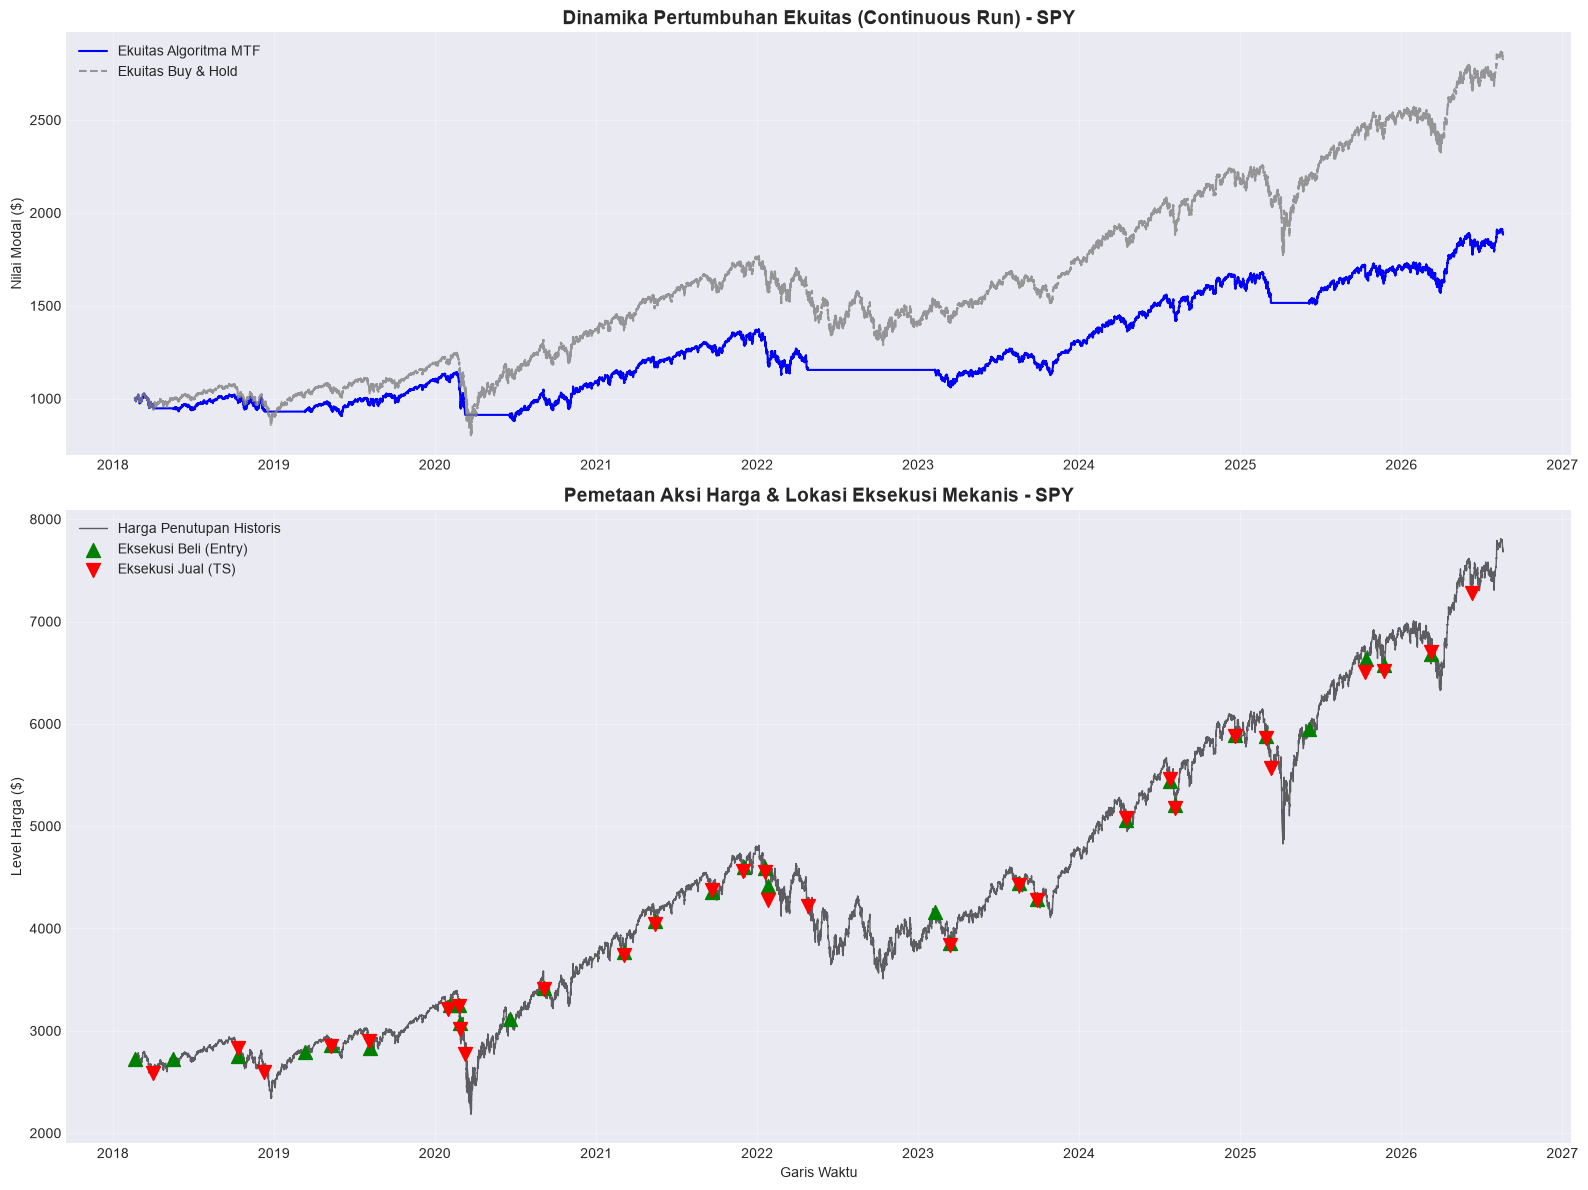

In [38]:
# =============================================================================
# BLOK 6: EKSEKUSI & EVALUASI S&P 500 (SPY)
# =============================================================================
if 'spy_1d' in locals():
    df_spy_merged, log_spy = run_backtest(spy_1d, spy_1h, 'SPY')
    eval_spy_strat, eval_spy_bh = evaluasi_fase_pasar(df_spy_merged, log_spy, 'S&P 500 (SPY)')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 1.5]})
    ax1.plot(df_spy_merged.index, df_spy_merged['Equity_Strat'], label='Ekuitas Algoritma MTF', color='blue', linewidth=1.5)
    ax1.plot(df_spy_merged.index, df_spy_merged['Equity_BH'], label='Ekuitas Buy & Hold', color='gray', linestyle='--', alpha=0.8)
    ax1.set_title("Dinamika Pertumbuhan Ekuitas (Continuous Run) - SPY", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Nilai Modal ($)")
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(df_spy_merged.index, df_spy_merged['close'], label='Harga Penutupan Historis', color='black', linewidth=1, alpha=0.6)
    if len(log_spy) > 0:
        ax2.scatter(log_spy['Buy_Date'], log_spy['Buy_Price'], marker='^', color='green', s=100, label='Eksekusi Beli (Entry)', zorder=5)
        ax2.scatter(log_spy['Sell_Date'], log_spy['Sell_Price'], marker='v', color='red', s=100, label='Eksekusi Jual (TS)', zorder=5)
    ax2.set_title("Pemetaan Aksi Harga & Lokasi Eksekusi Mekanis - SPY", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Level Harga ($)")
    ax2.set_xlabel("Garis Waktu")
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()




HASIL EVALUASI FASE PASAR - [NASDAQ 100 (QQQ)]

[TABEL 1: PERFORMA STRATEGI TRADING]
          Fase Pasar Return(%) CAGR(%) Max DD(%) Win Rate(%) R/R Ratio Sortino Time(%) Trades
Keseluruhan Berjalan    376.69   18.82    -30.51       61.54      2.33    1.16   79.56     26
             Bullish    343.78   23.47    -27.45       69.57      2.37    1.47   98.78     23
             Bearish     13.52   10.30     -6.06        0.00      0.00   11.66    3.45      0
            Sideways     -5.38   -7.65    -19.14        0.00      0.00   -0.49   25.73      3

[TABEL 2: PERFORMA BUY & HOLD (B&H)]
          Fase Pasar Return(%) CAGR(%) Max DD(%) Sharpe Sortino
Keseluruhan Berjalan    415.35   19.85    -37.25   0.90    1.18
             Bullish    339.45   23.30    -28.71   1.20    1.43
             Bearish     29.83   22.36    -27.41   0.73    1.26
            Sideways     -9.67  -13.63    -20.06  -0.29   -0.38

Sampel Log Transaksi (5 Terakhir):
Symbol            Buy_Date  Buy_Price           Sel

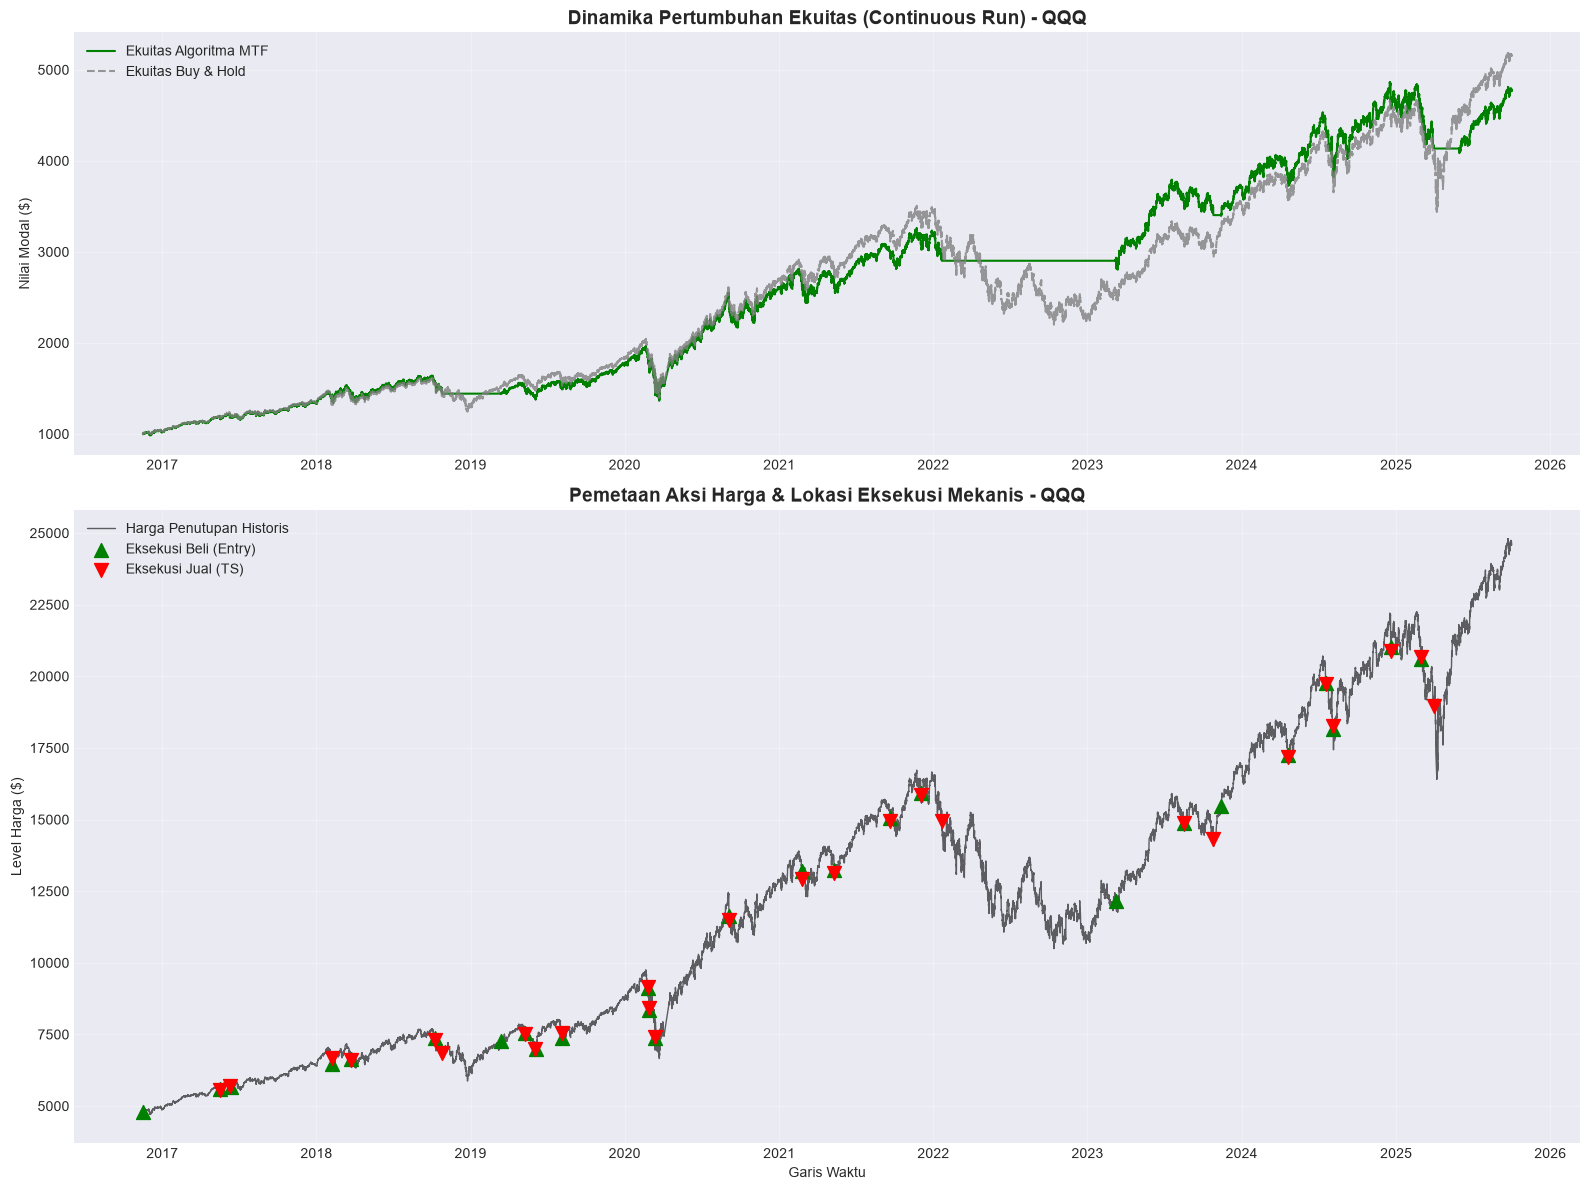

In [39]:
# =============================================================================
# BLOK 7: EKSEKUSI & EVALUASI NASDAQ 100 (QQQ)
# =============================================================================
if 'qqq_1d' in locals():
    df_qqq_merged, log_qqq = run_backtest(qqq_1d, qqq_1h, 'QQQ')
    eval_qqq_strat, eval_qqq_bh = evaluasi_fase_pasar(df_qqq_merged, log_qqq, 'NASDAQ 100 (QQQ)')
    # eval_qqq_strat, eval_qqq_bh = evaluasi_fase_pasar(df_qqq_merged, log_qqq, 'NASDAQ 100 (QQQ)')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 1.5]})
    ax1.plot(df_qqq_merged.index, df_qqq_merged['Equity_Strat'], label='Ekuitas Algoritma MTF', color='green', linewidth=1.5)
    ax1.plot(df_qqq_merged.index, df_qqq_merged['Equity_BH'], label='Ekuitas Buy & Hold', color='gray', linestyle='--', alpha=0.8)
    ax1.set_title("Dinamika Pertumbuhan Ekuitas (Continuous Run) - QQQ", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Nilai Modal ($)")
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(df_qqq_merged.index, df_qqq_merged['close'], label='Harga Penutupan Historis', color='black', linewidth=1, alpha=0.6)
    if len(log_qqq) > 0:
        ax2.scatter(log_qqq['Buy_Date'], log_qqq['Buy_Price'], marker='^', color='green', s=100, label='Eksekusi Beli (Entry)', zorder=5)
        ax2.scatter(log_qqq['Sell_Date'], log_qqq['Sell_Price'], marker='v', color='red', s=100, label='Eksekusi Jual (TS)', zorder=5)
    ax2.set_title("Pemetaan Aksi Harga & Lokasi Eksekusi Mekanis - QQQ", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Level Harga ($)")
    ax2.set_xlabel("Garis Waktu")
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



HASIL EVALUASI FASE PASAR - [DOW JONES (DJI)]

[TABEL 1: PERFORMA STRATEGI TRADING]
          Fase Pasar Return(%) CAGR(%) Max DD(%) Win Rate(%) R/R Ratio Sortino Time(%) Trades
Keseluruhan Berjalan     26.75    2.69    -28.08       50.00      1.48    0.29   75.23     32
             Bullish     35.00    4.79    -26.59       61.54      1.81    0.53   97.44     26
             Bearish      0.00    0.00      0.00        0.00      0.00    0.00    0.00      0
            Sideways     -6.11   -5.03    -15.30        0.00      0.00   -0.54   38.36      6

[TABEL 2: PERFORMA BUY & HOLD (B&H)]
          Fase Pasar Return(%) CAGR(%) Max DD(%) Sharpe Sortino
Keseluruhan Berjalan    142.83   10.45    -38.30   0.65    0.77
             Bullish     46.09    6.09    -24.38   0.54    0.68
             Bearish     65.45   47.58    -20.97   1.51    2.08
            Sideways      0.46    0.38    -24.48   0.11    0.12

Sampel Log Transaksi (5 Terakhir):
Symbol            Buy_Date  Buy_Price           Sell

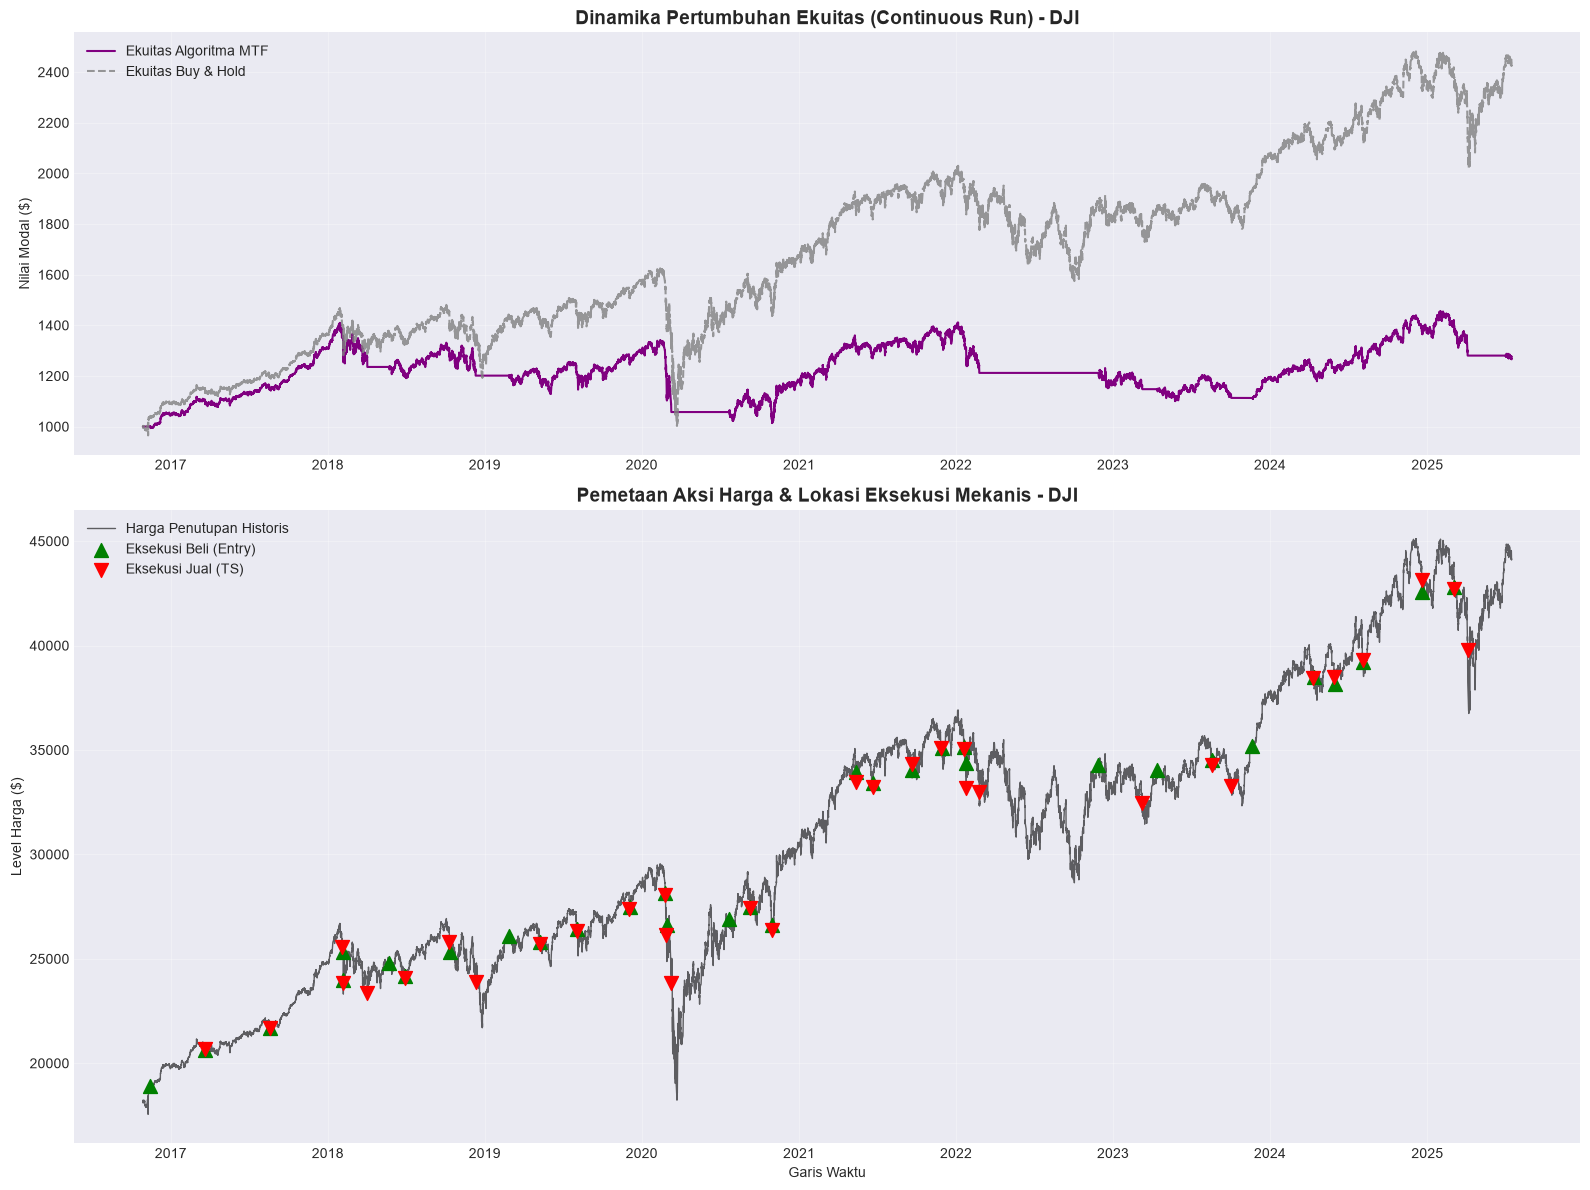

In [40]:
# =============================================================================
# BLOK 8: EKSEKUSI & EVALUASI DOW JONES (DJI)
# =============================================================================
if 'dji_1d' in locals():
    df_dji_merged, log_dji = run_backtest(dji_1d, dji_1h, 'DJI')
    # eval_dji_strat, eval_dji_bh = evaluasi_fase_pasar(df_dji_merged, log_dji, 'DOW JONES (DJI)')
    eval_dji_strat, eval_dji_bh = evaluasi_fase_pasar(df_dji_merged, log_dji, 'DOW JONES (DJI)')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 1.5]})
    ax1.plot(df_dji_merged.index, df_dji_merged['Equity_Strat'], label='Ekuitas Algoritma MTF', color='purple', linewidth=1.5)
    ax1.plot(df_dji_merged.index, df_dji_merged['Equity_BH'], label='Ekuitas Buy & Hold', color='gray', linestyle='--', alpha=0.8)
    ax1.set_title("Dinamika Pertumbuhan Ekuitas (Continuous Run) - DJI", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Nilai Modal ($)")
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(df_dji_merged.index, df_dji_merged['close'], label='Harga Penutupan Historis', color='black', linewidth=1, alpha=0.6)
    if len(log_dji) > 0:
        ax2.scatter(log_dji['Buy_Date'], log_dji['Buy_Price'], marker='^', color='green', s=100, label='Eksekusi Beli (Entry)', zorder=5)
        ax2.scatter(log_dji['Sell_Date'], log_dji['Sell_Price'], marker='v', color='red', s=100, label='Eksekusi Jual (TS)', zorder=5)
    ax2.set_title("Pemetaan Aksi Harga & Lokasi Eksekusi Mekanis - DJI", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Level Harga ($)")
    ax2.set_xlabel("Garis Waktu")
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

